# SPY — Regression Models (Iteration 3)

Walk-forward config: **train=3d / test=1d / embargo=0d** (~2,507 folds)

Predicts **5-day forward realized volatility** (`target_volatility`) using Linear Regression, Ridge Regression, and XGBoost.

> **Caution:** Iteration 3 uses an extremely short training window (3 days). This notebook serves as a cautionary example of underdetermined models. R² is NaN per fold because `test_window=1` provides only a single test sample, making r2_score undefined.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
spy_raw = pd.read_csv("../data/SPY_features.csv", parse_dates=["date"], index_col="date")
print(f"SPY: {len(spy_raw):,} rows | {spy_raw.index[0].date()} → {spy_raw.index[-1].date()}")

SPY: 2,515 rows | 2015-01-02 → 2024-12-30


In [3]:
FEATURES = [
    "daily_return", "weekly_return", "lag_return_1", "lag_return_3", "lag_return_5",
    "dist_from_ma21", "ma_cross",
    "macd_hist",
    "daily_range", "volatility_20", "bb_position",
    "volume_change", "volume_ratio",
    "rsi_14",
    "is_major_event", "is_earnings_week",
]

TRAIN_WINDOW = 3
TEST_WINDOW  = 1
EMBARGO      = 0


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=EMBARGO):
    splits = []
    n = len(df)
    start = 0
    while start + train_window + embargo + test_window <= n:
        train_idx  = list(range(start, start + train_window))
        test_start = start + train_window + embargo
        test_idx   = list(range(test_start, test_start + test_window))
        splits.append((train_idx, test_idx))
        start += test_window
    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values
    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

In [4]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("LINEAR REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds) if len(y_test) > 1 else float("nan")
        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "r2": r2})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Note: R²=NaN per fold — test_window=1 provides only 1 sample (r2_score undefined)")
    return last_model, metrics_df, preds_df, coef_df

In [5]:
def run_ridge_regression(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("RIDGE REGRESSION — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds) if len(y_test) > 1 else float("nan")
        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "r2": r2})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Note: R²=NaN per fold — test_window=1 provides only 1 sample (r2_score undefined)")
    return last_model, metrics_df, preds_df, coef_df

In [6]:
def run_xgboost(df):
    splits = walk_forward_splits(df)
    print("\n" + "="*55)
    print("XGBOOST — 5-day forward volatility")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)
    fold_metrics, all_preds, fold_coefs, last_model = [], [], [], None
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_volatility", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds) if len(y_test) > 1 else float("nan")
        fold_metrics.append({"fold": fold, "mae": mae, "rmse": rmse, "r2": r2})
        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})
        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})
        last_model = model
    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)
    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")
    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))
    return last_model, metrics_df, preds_df, coef_df

In [7]:
def naive_baseline(df):
    splits = walk_forward_splits(df)
    tv = df["target_volatility"].values
    all_preds = []
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        for i in test_idx:
            lag_idx = i - 1
            if lag_idx >= 0 and not np.isnan(tv[lag_idx]):
                all_preds.append({"date": df.index[i], "actual": tv[i], "predicted": tv[lag_idx]})
    preds_df = pd.DataFrame(all_preds).dropna()
    rmse = np.sqrt(mean_squared_error(preds_df["actual"], preds_df["predicted"]))
    mae  = mean_absolute_error(preds_df["actual"], preds_df["predicted"])
    print("\n" + "="*55)
    print("NAIVE BASELINE — lag-1 volatility persistence")
    print("="*55)
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print("  (Baseline: yesterday's volatility predicts today's)")
    return preds_df, rmse, mae

In [8]:
def regime_summary(preds_df, source_df, label=""):
    df = preds_df.copy()
    df = df.merge(source_df[["is_major_event"]], left_on="date", right_index=True, how="left")
    header = f"REGIME BREAKDOWN — {label}" if label else "REGIME BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)
    rows = []
    for regime, flag in [("Normal (VIX ≤ 30)", 0), ("Stress (VIX > 30)", 1)]:
        s = df[df["is_major_event"] == flag].dropna(subset=["actual", "predicted"])
        if len(s) < 2:
            continue
        rmse = np.sqrt(mean_squared_error(s["actual"], s["predicted"]))
        mae  = mean_absolute_error(s["actual"], s["predicted"])
        r2   = r2_score(s["actual"], s["predicted"]) if len(s) > 1 else float("nan")
        rows.append({"regime": regime, "n": len(s), "rmse": round(rmse, 6),
                     "mae": round(mae, 6), "r2": round(r2, 4)})
    result = pd.DataFrame(rows) if rows else pd.DataFrame()
    print(result.to_string(index=False))
    return result

In [9]:
# ── Targets ──────────────────────────────────────────────────────────────
spy_raw["target_volatility"] = (
    spy_raw["close"].pct_change()
    .shift(-1)
    .rolling(5)
    .std()
    .shift(-4)
)

required_cols = FEATURES + ["target_volatility"]
spy_df = spy_raw.dropna(subset=required_cols).copy()

print(f"Rows after dropping NaN: {len(spy_df):,}")
print(f"Date range: {spy_df.index.min().date()} → {spy_df.index.max().date()}")
print(f"Major event days (VIX > 30): {spy_df['is_major_event'].sum()}")
print(f"Walk-forward folds: {len(walk_forward_splits(spy_df))}")

# ── Run models ────────────────────────────────────────────────────────────
lin_model,   lin_metrics,   lin_preds,   lin_coefs   = run_linear_regression(spy_df)
ridge_model, ridge_metrics, ridge_preds, ridge_coefs = run_ridge_regression(spy_df)
xgb_model,   xgb_metrics,   xgb_preds,   xgb_coefs   = run_xgboost(spy_df)

# ── Naive baseline ────────────────────────────────────────────────────────
naive_preds, naive_rmse, naive_mae = naive_baseline(spy_df)

# ── Regime summaries ──────────────────────────────────────────────────────
regime_summary(lin_preds,   spy_df, "Linear Regression — SPY")
regime_summary(ridge_preds, spy_df, "Ridge Regression — SPY")
regime_summary(xgb_preds,   spy_df, "XGBoost — SPY")

Rows after dropping NaN: 2,510
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Walk-forward folds: 2507

LINEAR REGRESSION — 5-day forward volatility
Walk-forward: 2507 folds  (train=3d, test=1d)

  Metric          Mean         Std
  --------------------------------
  RMSE        0.002496  ±  0.004214
  MAE         0.002496  ±  0.004214
  R²               nan  ±       nan

  Note: R²=NaN per fold — test_window=1 provides only 1 sample (r2_score undefined)

RIDGE REGRESSION — 5-day forward volatility
Walk-forward: 2507 folds  (train=3d, test=1d)

  Metric          Mean         Std
  --------------------------------
  RMSE        0.002433  ±  0.004024
  MAE         0.002433  ±  0.004024
  R²               nan  ±       nan

  Note: R²=NaN per fold — test_window=1 provides only 1 sample (r2_score undefined)

XGBOOST — 5-day forward volatility
Walk-forward: 2507 folds  (train=3d, test=1d)

  Metric          Mean         Std
  --------------------------------
  RMSE     

,regime,n,rmse,mae,r2
0,Normal (VIX ≤ 30),2363,0.003090,0.001980,0.6078
1,Stress (VIX > 30),144,0.007889,0.005464,0.7690


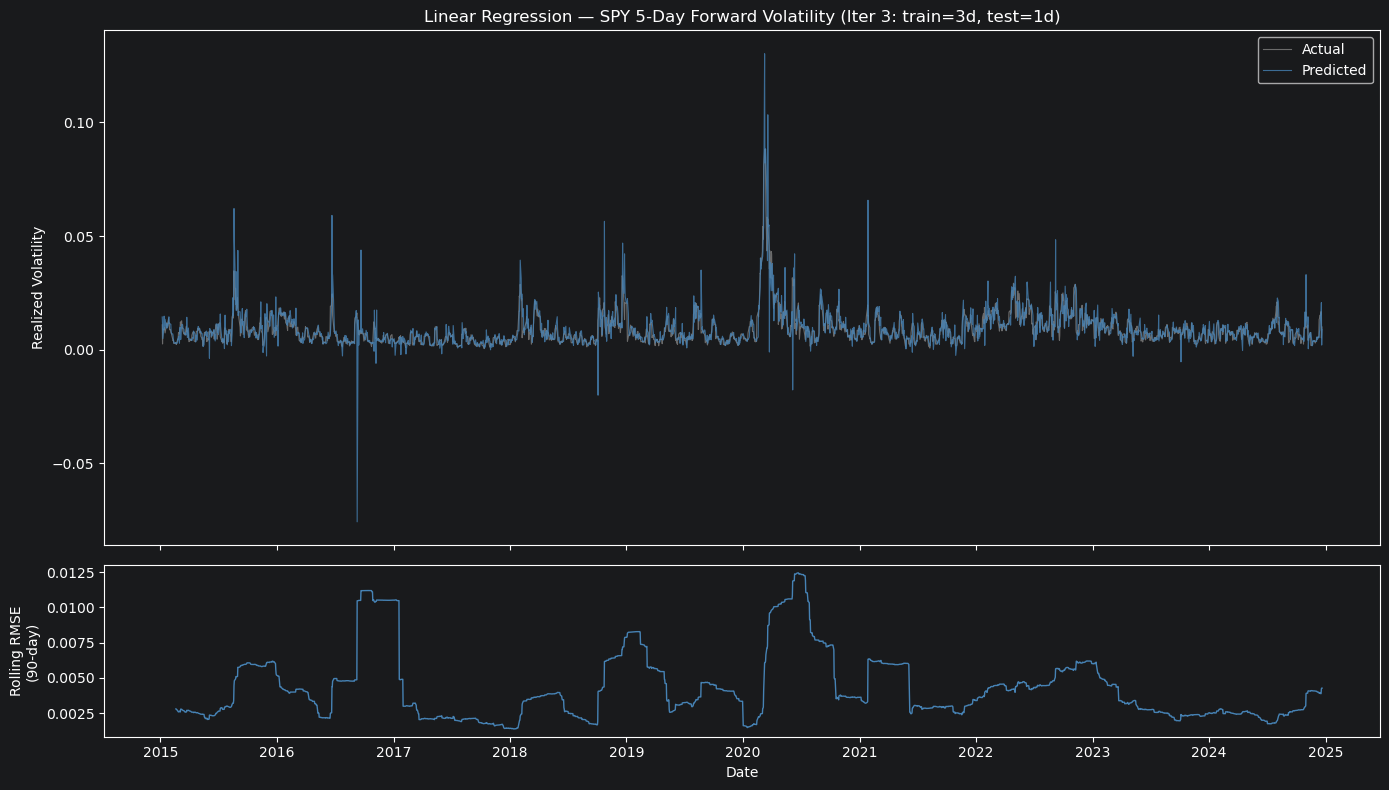

Saved: img/spy_iter3_linear_regression_line.png


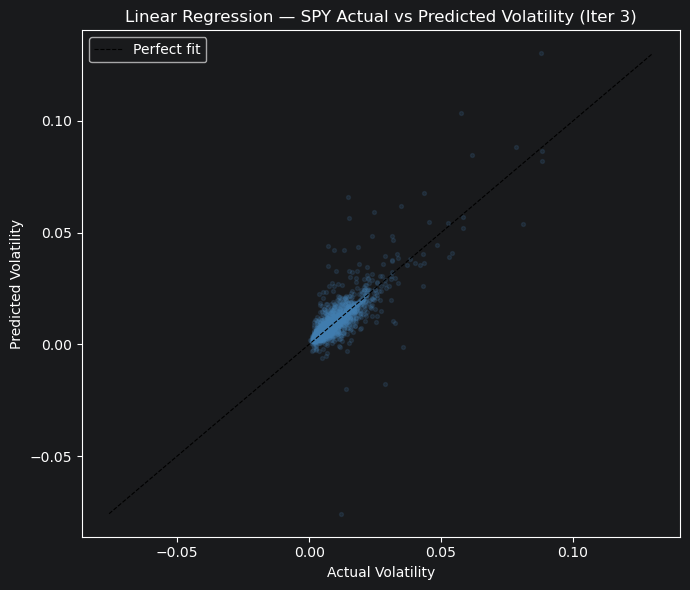

Saved: img/spy_iter3_linear_regression_scatter.png


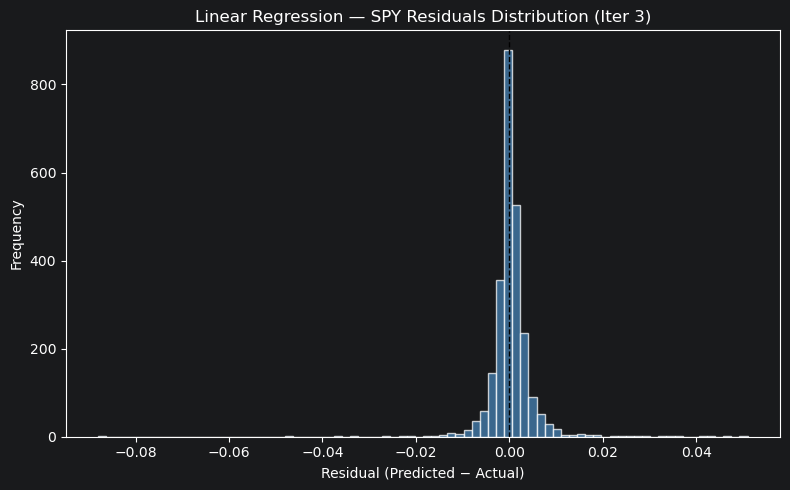

Saved: img/spy_iter3_linear_regression_residuals.png


In [10]:
# ── LINEAR REGRESSION — 3 plots ──────────────────────────────────────────
p = lin_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line (actual vs predicted + rolling RMSE)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",     linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="steelblue", linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("Linear Regression — SPY 5-Day Forward Volatility (Iter 3: train=3d, test=1d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="steelblue", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter3_linear_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_linear_regression_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.15, s=8, color="steelblue")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("Linear Regression — SPY Actual vs Predicted Volatility (Iter 3)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter3_linear_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_linear_regression_scatter.png")

# Plot 3: residuals histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Linear Regression — SPY Residuals Distribution (Iter 3)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter3_linear_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_linear_regression_residuals.png")

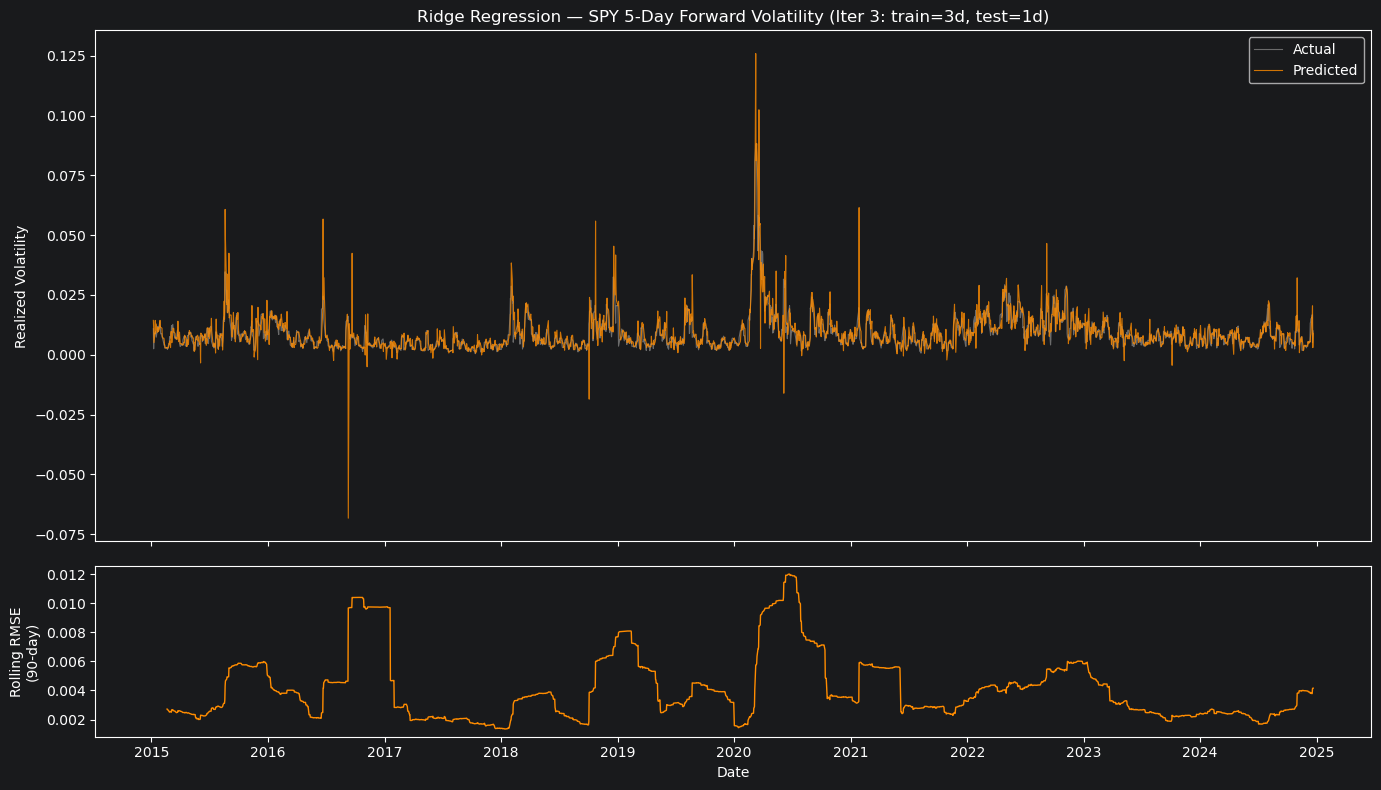

Saved: img/spy_iter3_ridge_regression_line.png


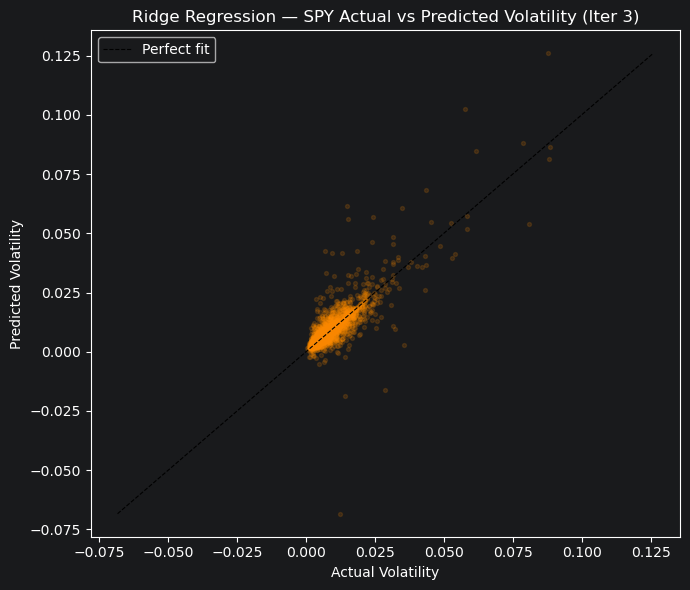

Saved: img/spy_iter3_ridge_regression_scatter.png


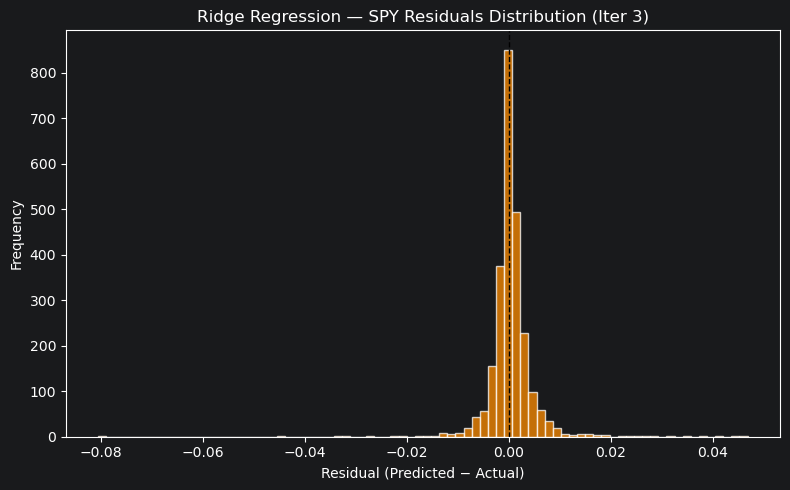

Saved: img/spy_iter3_ridge_regression_residuals.png


In [11]:
# ── RIDGE REGRESSION — 3 plots ───────────────────────────────────────────
p = ridge_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",       linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="darkorange",  linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("Ridge Regression — SPY 5-Day Forward Volatility (Iter 3: train=3d, test=1d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="darkorange", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter3_ridge_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_ridge_regression_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.15, s=8, color="darkorange")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("Ridge Regression — SPY Actual vs Predicted Volatility (Iter 3)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter3_ridge_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_ridge_regression_scatter.png")

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="darkorange", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Ridge Regression — SPY Residuals Distribution (Iter 3)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter3_ridge_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_ridge_regression_residuals.png")

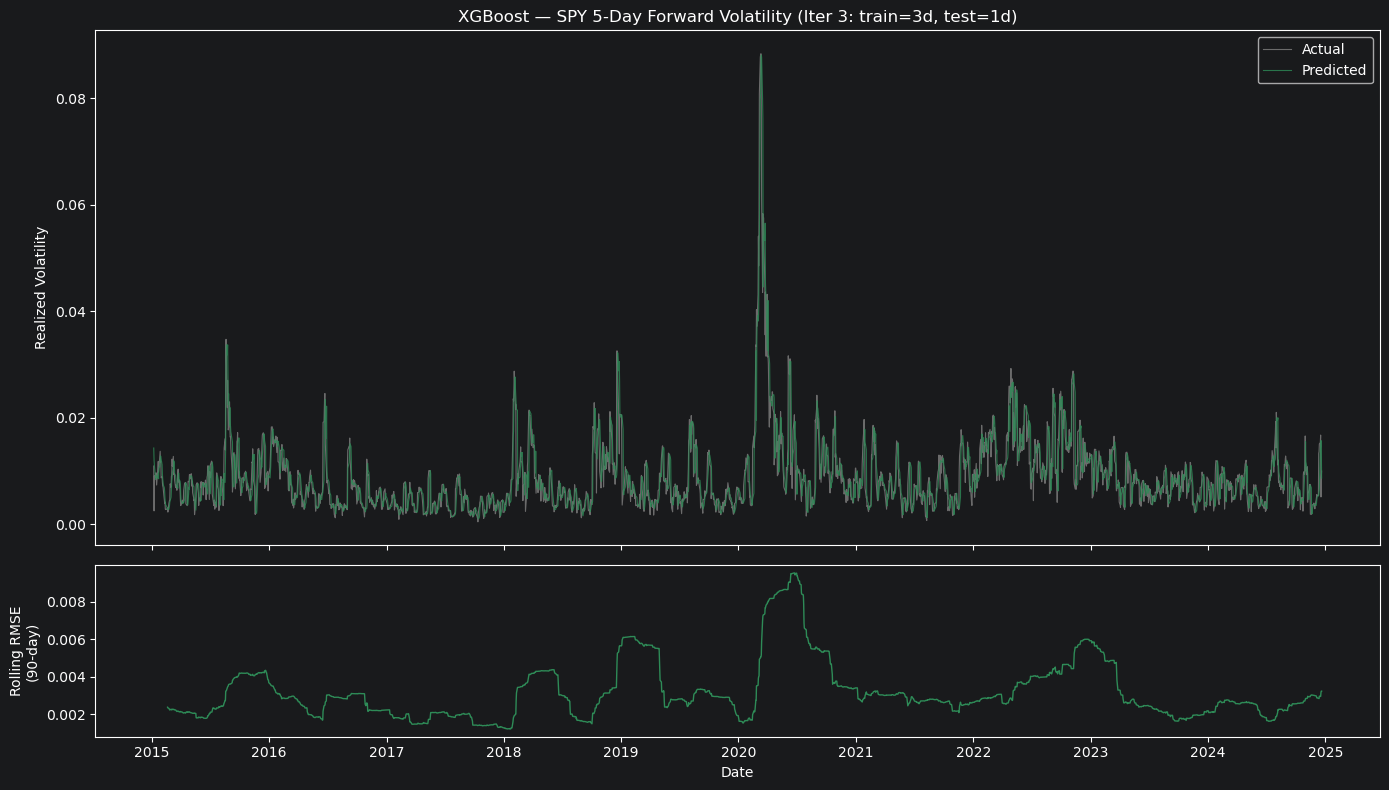

Saved: img/spy_iter3_xgboost_line.png


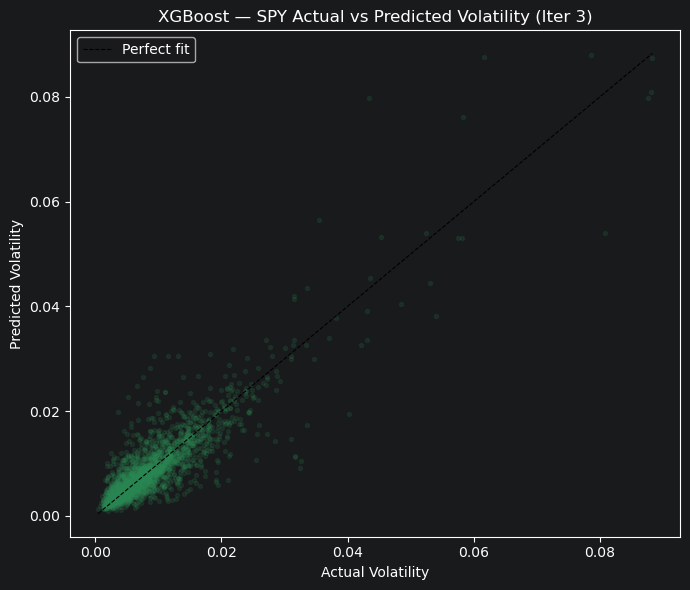

Saved: img/spy_iter3_xgboost_scatter.png


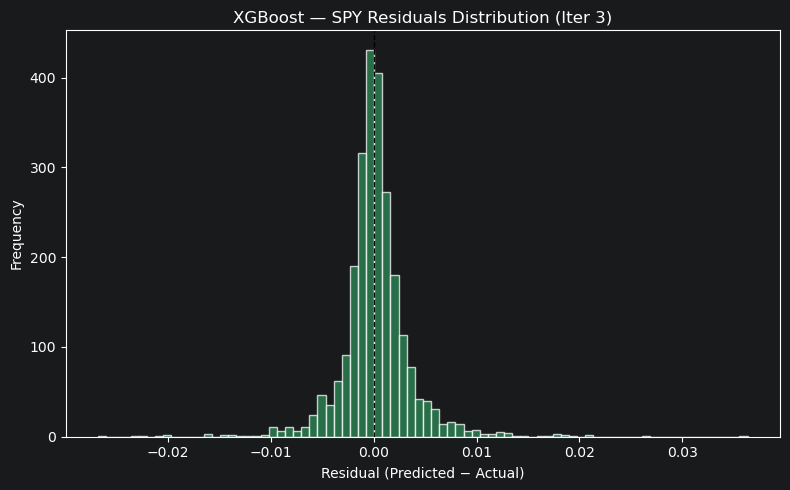

Saved: img/spy_iter3_xgboost_residuals.png


In [12]:
# ── XGBOOST — 3 plots ────────────────────────────────────────────────────
p = xgb_preds.copy()
p["date"] = pd.to_datetime(p["date"])
p = p.sort_values("date")
p["residual"] = p["predicted"] - p["actual"]
p["abs_residual"] = p["residual"].abs()
p["rolling_rmse"] = p["abs_residual"].rolling(90, min_periods=30).apply(
    lambda x: np.sqrt((x**2).mean())
)

# Plot 1: line
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(p["date"], p["actual"],    color="gray",     linewidth=0.8, alpha=0.8, label="Actual")
ax1.plot(p["date"], p["predicted"], color="seagreen",  linewidth=0.8, alpha=0.8, label="Predicted")
ax1.set_title("XGBoost — SPY 5-Day Forward Volatility (Iter 3: train=3d, test=1d)")
ax1.set_ylabel("Realized Volatility")
ax1.legend()
ax2.plot(p["date"], p["rolling_rmse"], color="seagreen", linewidth=1.0)
ax2.set_ylabel("Rolling RMSE\n(90-day)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("img/spy_iter3_xgboost_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_xgboost_line.png")

# Plot 2: scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(p["actual"], p["predicted"], alpha=0.15, s=8, color="seagreen")
lims = [min(p["actual"].min(), p["predicted"].min()),
        max(p["actual"].max(), p["predicted"].max())]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect fit")
ax.set_title("XGBoost — SPY Actual vs Predicted Volatility (Iter 3)")
ax.set_xlabel("Actual Volatility")
ax.set_ylabel("Predicted Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("img/spy_iter3_xgboost_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_xgboost_scatter.png")

# Plot 3: residuals
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(p["residual"], bins=80, color="seagreen", alpha=0.75, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("XGBoost — SPY Residuals Distribution (Iter 3)")
ax.set_xlabel("Residual (Predicted − Actual)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("img/spy_iter3_xgboost_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter3_xgboost_residuals.png")

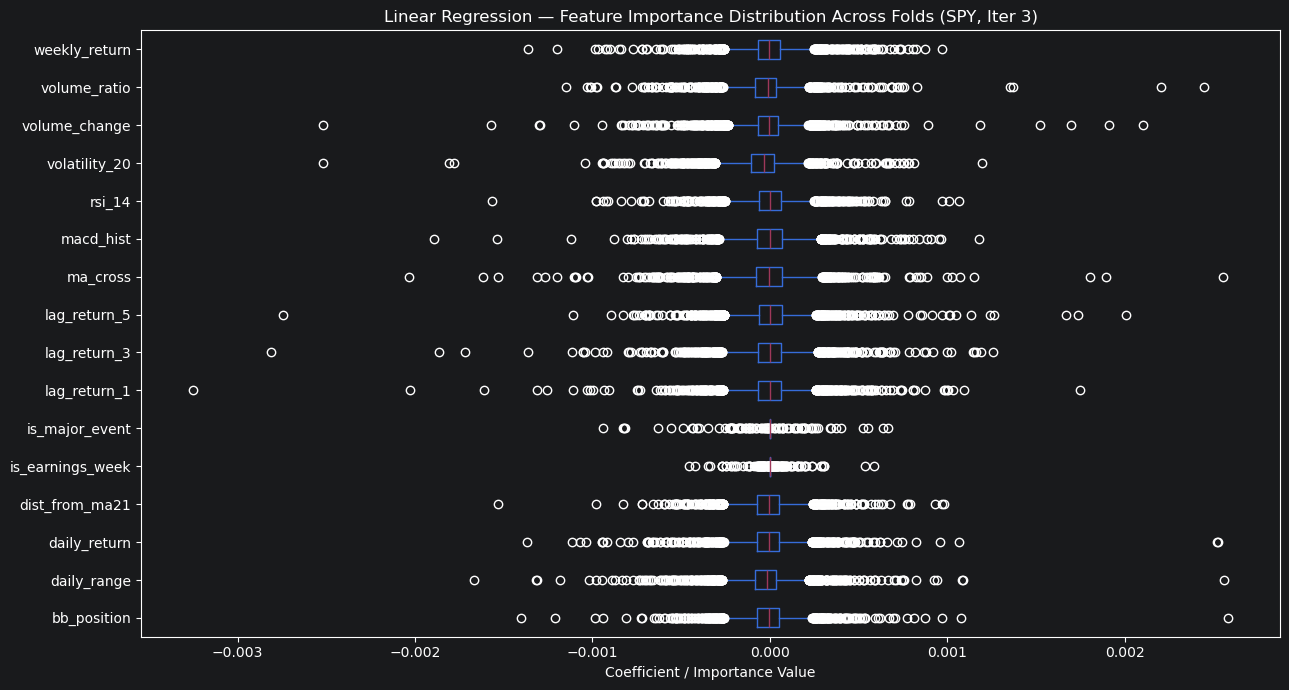

Saved: img/spy_iter3_linear_regression_coef_stability.png


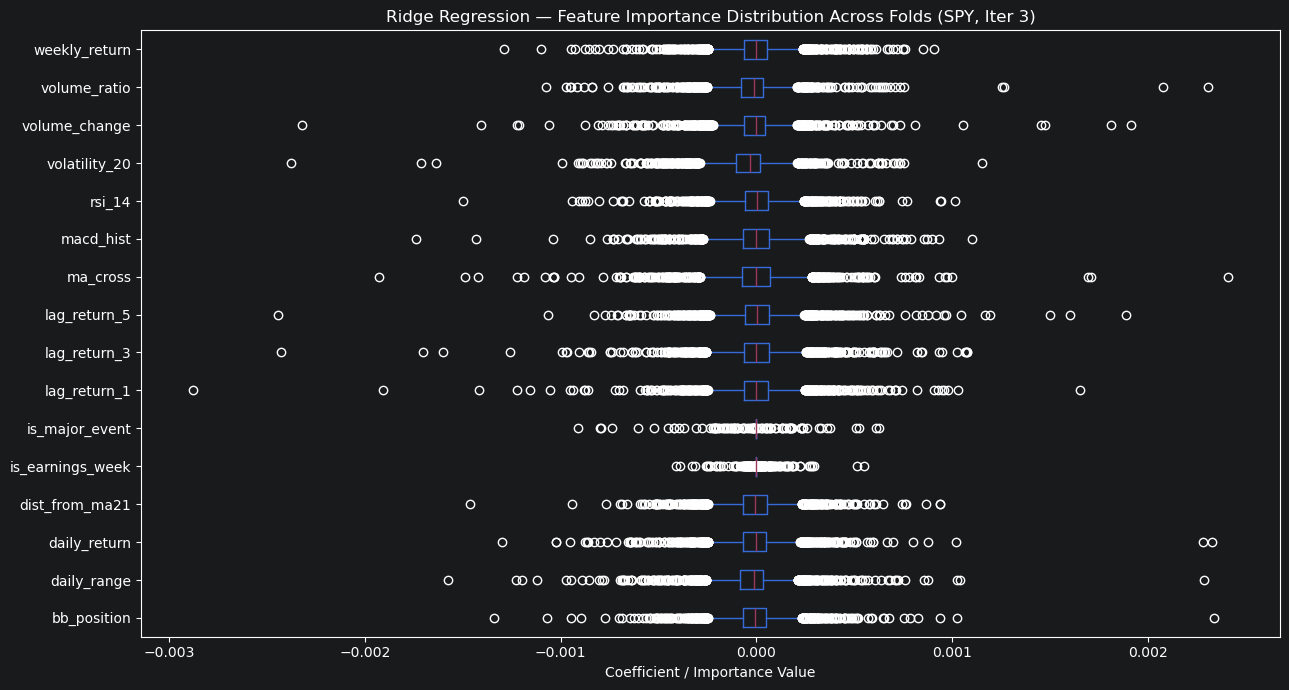

Saved: img/spy_iter3_ridge_regression_coef_stability.png


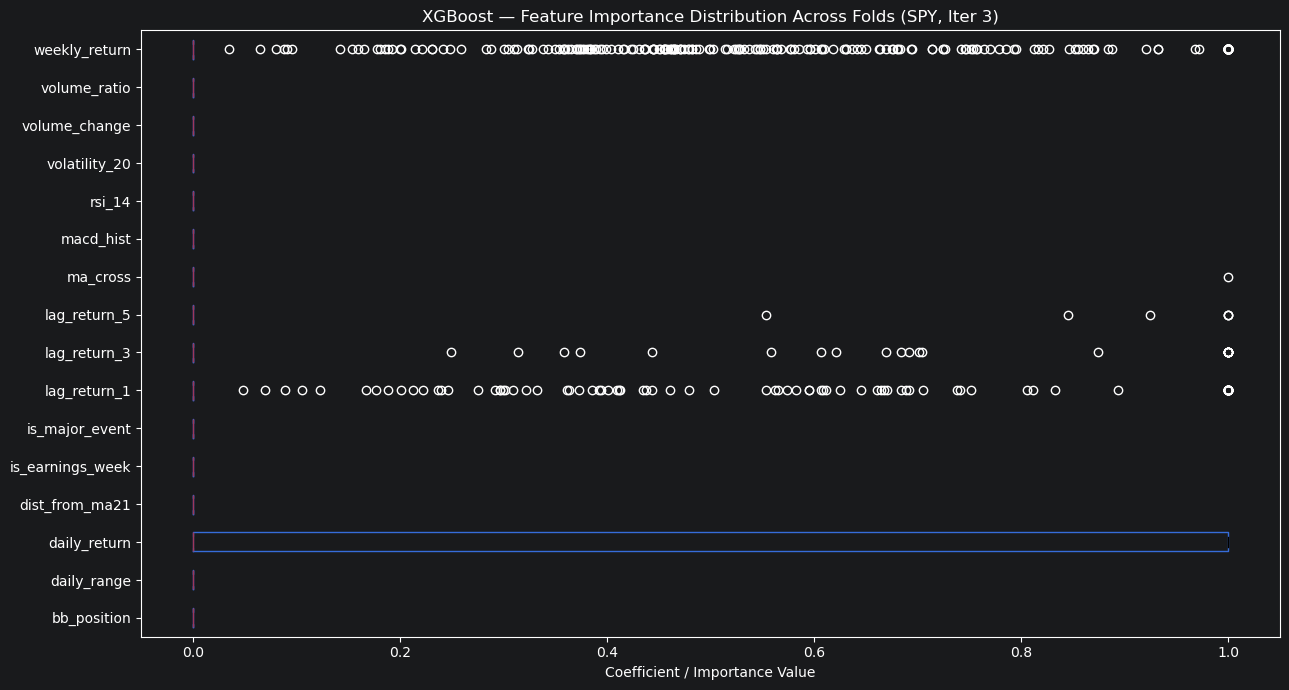

Saved: img/spy_iter3_xgboost_coef_stability.png


In [13]:
# ── COEFFICIENT / FEATURE IMPORTANCE STABILITY ───────────────────────────
for coef_df, label, color in [
    (lin_coefs,   "Linear Regression", "steelblue"),
    (ridge_coefs, "Ridge Regression",  "darkorange"),
    (xgb_coefs,   "XGBoost",           "seagreen"),
]:
    pivot = coef_df.pivot(index="fold", columns="feature", values="value")
    fig, ax = plt.subplots(figsize=(13, 7))
    pivot.boxplot(ax=ax, vert=False, grid=False)
    ax.set_title(f"{label} — Feature Importance Distribution Across Folds (SPY, Iter 3)")
    ax.set_xlabel("Coefficient / Importance Value")
    plt.tight_layout()
    fname = label.lower().replace(" ", "_")
    plt.savefig(f"img/spy_iter3_{fname}_coef_stability.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: img/spy_iter3_{fname}_coef_stability.png")

## Red Flags — Iteration 3 (SPY Regression)

Iteration 3 uses train=3d / test=1d — an extremely short window that renders models statistically underdetermined. This notebook is a **cautionary case**, not a reliable predictor.

| Issue | Detail |
|---|---|
| **RMSE std > RMSE mean** | Linear: std=0.004214 > mean=0.002496; Ridge: std=0.004024 > mean=0.002433; XGBoost: std=0.002797 > mean=0.002181. High fold-to-fold variance indicates extreme instability — the model's error varies more than its average error. |
| **R²=NaN per fold** | `test_window=1` provides a single test sample per fold; `r2_score` is undefined for n=1. Per-fold R² cannot be computed. Aggregate seasonal R² (computed over pooled predictions) partially compensates but masks fold instability. |
| **XGBoost feature collapse** | Last fold: `weekly_return`=0.86, `daily_return`=0.14 — 86% of importance on one feature. With only 3 training samples, XGBoost converges on the most correlated feature rather than learning a generalizable combination. |
| **Seasonal R² divergence** | Ridge: Spring R²=+0.82 vs Fall R²=−0.10 — a 0.92-point spread. Aggregate statistics mask the fact that the model works well in some seasons and actively harms predictions in others. |
| **Underdetermined linear models** | With 16 features and only 3 training samples, LinearRegression is fitting noise. The system is rank-deficient; `is_major_event` and `is_earnings_week` receive zero coefficient because they are constant within most 3-day windows. |